# Synthetic vp/vs Ellipsoid DLI

This notebook is a synthetic DLI example that extends `synthetic_vp_vs_dli.ipynb` by replacing both norm-ball constraints with **ellipsoids**. The model prior is constructed operator-theoretically using Bessel operators on basis-free function spaces — no dense covariance matrices and no model-space discretisation.

The model space is the direct sum
$$
\mathcal{M} = \mathcal{M}_{vp} \oplus \mathcal{M}_{vs},
$$
and the admissible property set is
$$
\mathcal{U} = \mathcal{T}\!\left(\mathcal{E} \cap G^{-1}(\tilde{d} - \mathcal{V})\right),
$$
where:
- $\mathcal{E} = \bigl\{m : \langle C_0^{-1} m, m \rangle_{\mathcal{M}} \leq \chi^2_{d_{\rm eff}}(0.95)\bigr\}$ is the 0.95-confidence ellipsoid of the block-diagonal Bessel-Sobolev prior covariance $C_0$.
- $\mathcal{V} = \bigl\{\eta \in \mathbb{R}^{N_d} : \sum_i (\eta_i / \sigma_{d,i})^2 \leq \chi^2_{N_d}(0.95)\bigr\}$ is a **heteroscedastic** data ellipsoid in $\mathbb{R}^{N_d}$ defined by the 0.95-quantile of a chi-squared distribution with $N_d$ degrees of freedom.

The key difference from `synthetic_vp_vs_dli.ipynb` is that both constraints are **ellipsoids** rather than norm balls: the model prior encodes spatial correlation length and smoothness via `BesselSobolev` operators, and the data-confidence set accounts for per-datum noise variance via a `DiagonalSparseMatrixLinearOperator`. The DLI dual-master cost function and `ProximalBundleMethod` solve are otherwise identical in structure to the ball-constrained version.

In [16]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2 as scipy_chi2

from intervalinf import (
    IntervalDomain, Lebesgue, Function,
    IntegrationConfig, ParallelConfig, LebesgueIntegrationConfig,
    BoundaryConditions,
)
from intervalinf.providers import NormalModesProvider, BumpFunctionProvider, NullFunctionProvider
from intervalinf.operators import SOLAOperator, Laplacian, BesselSobolev, BesselSobolevInverse
from intervalinf.sampling import KLSampler

from pygeoinf import (
    EuclideanSpace,
    RowLinearOperator,
    HilbertSpaceDirectSum,
    EllipsoidSupportFunction,
    DiagonalSparseMatrixLinearOperator,
)
from pygeoinf.direct_sum import BlockDiagonalLinearOperator
from pygeoinf.backus_gilbert import DualMasterCostFunction
from pygeoinf.convex_optimisation import (
    ProximalBundleMethod,
    solve_support_values,
    best_available_qp_solver,
)

figures_folder = 'synthetic_vp_vs_ellipsoid_dli_figures'
os.makedirs(figures_folder, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
print('Imports OK')


Imports OK


## Numerical Configuration

The model spaces are continuous Lebesgue spaces on $[0, 1]$, kept basis-free (`basis=None`). Integration is performed numerically by the operators. We keep the grid modest so the notebook runs quickly.

In [11]:
Lebesgue_integration_cfg = LebesgueIntegrationConfig(
    inner_product=IntegrationConfig(method='trapz', n_points=512),
    dual=IntegrationConfig(method='trapz', n_points=512),
    general=IntegrationConfig(method='trapz', n_points=512),
)

sola_integration_cfg = IntegrationConfig(method='trapz', n_points=768)
parallel_cfg = ParallelConfig(enabled=True, n_jobs=4)

function_domain = IntervalDomain(0.0, 1.0)

# Spectral helper count — used for Laplacian/Bessel operator setup and
# KL truncation only; NOT the dimension of the basis-free model spaces.
N = 10
N_d = 80    # forward data dimension
N_p = 2     # property dimension

# Basis-free function spaces — no discretisation
M_vp = Lebesgue(
    0, function_domain, basis=None,
    integration_config=Lebesgue_integration_cfg,
    parallel_config=parallel_cfg,
)
M_vs = Lebesgue(
    0, function_domain, basis=None,
    integration_config=Lebesgue_integration_cfg,
    parallel_config=parallel_cfg,
)
M_model = HilbertSpaceDirectSum([M_vp, M_vs])
D = EuclideanSpace(N_d)
P = EuclideanSpace(N_p)

x = function_domain.uniform_mesh(1000)   # visualisation grid

print(f'Domain         : [{function_domain.a}, {function_domain.b}]')
print(f'Model blocks   : vp + vs  (both basis=None)')
print(f'Data dim       : {N_d}')
print(f'Property dim   : {N_p}')
print(f'Spectral N     : {N}')

Domain         : [0.0, 1.0]
Model blocks   : vp + vs  (both basis=None)
Data dim       : 80
Property dim   : 2
Spectral N     : 10


## Synthetic Forward and Property Operators

Both `vp` and `vs` contribute to the synthetic forward operator through separate `NormalModesProvider` instances assembled into a block `RowLinearOperator`. The property operator targets two bump-function averages on the `vp` block only; the `vs` contribution to the property map is null.

In [12]:
vp_modes = NormalModesProvider(
    M_vp,
    n_modes_range=(2, 8),
    coeff_range=(-4.0, 4.0),
    gaussian_width_percent_range=(5, 18),
    freq_range=(0.2, 8.0),
    random_state=7,
)
vs_modes = NormalModesProvider(
    M_vs,
    n_modes_range=(3, 9),
    coeff_range=(-3.0, 3.0),
    gaussian_width_percent_range=(6, 20),
    freq_range=(0.3, 10.0),
    random_state=17,
)

G_vp = SOLAOperator(
    M_vp, D, vp_modes,
    cache_kernels=True,
    integration_config=sola_integration_cfg,
)
G_vs = SOLAOperator(
    M_vs, D, vs_modes,
    cache_kernels=True,
    integration_config=sola_integration_cfg,
)
G = RowLinearOperator([G_vp, G_vs])

width = 0.18
centers = np.linspace(
    function_domain.a + width / 2,
    function_domain.b - width / 2,
    N_p,
)
target_provider_vp = BumpFunctionProvider(M_vp, centers=centers, default_width=width)
target_provider_vs = NullFunctionProvider(M_vs)

T_vp = SOLAOperator(
    M_vp, P, target_provider_vp,
    cache_kernels=True,
    integration_config=sola_integration_cfg,
)
T_vs = SOLAOperator(
    M_vs, P, target_provider_vs,
    cache_kernels=True,
    integration_config=sola_integration_cfg,
)
T = RowLinearOperator([T_vp, T_vs])

print('Block operators created successfully')
print(f'Property centres: {np.round(centers, 3)}')

Block operators created successfully
Property centres: [0.09 0.91]


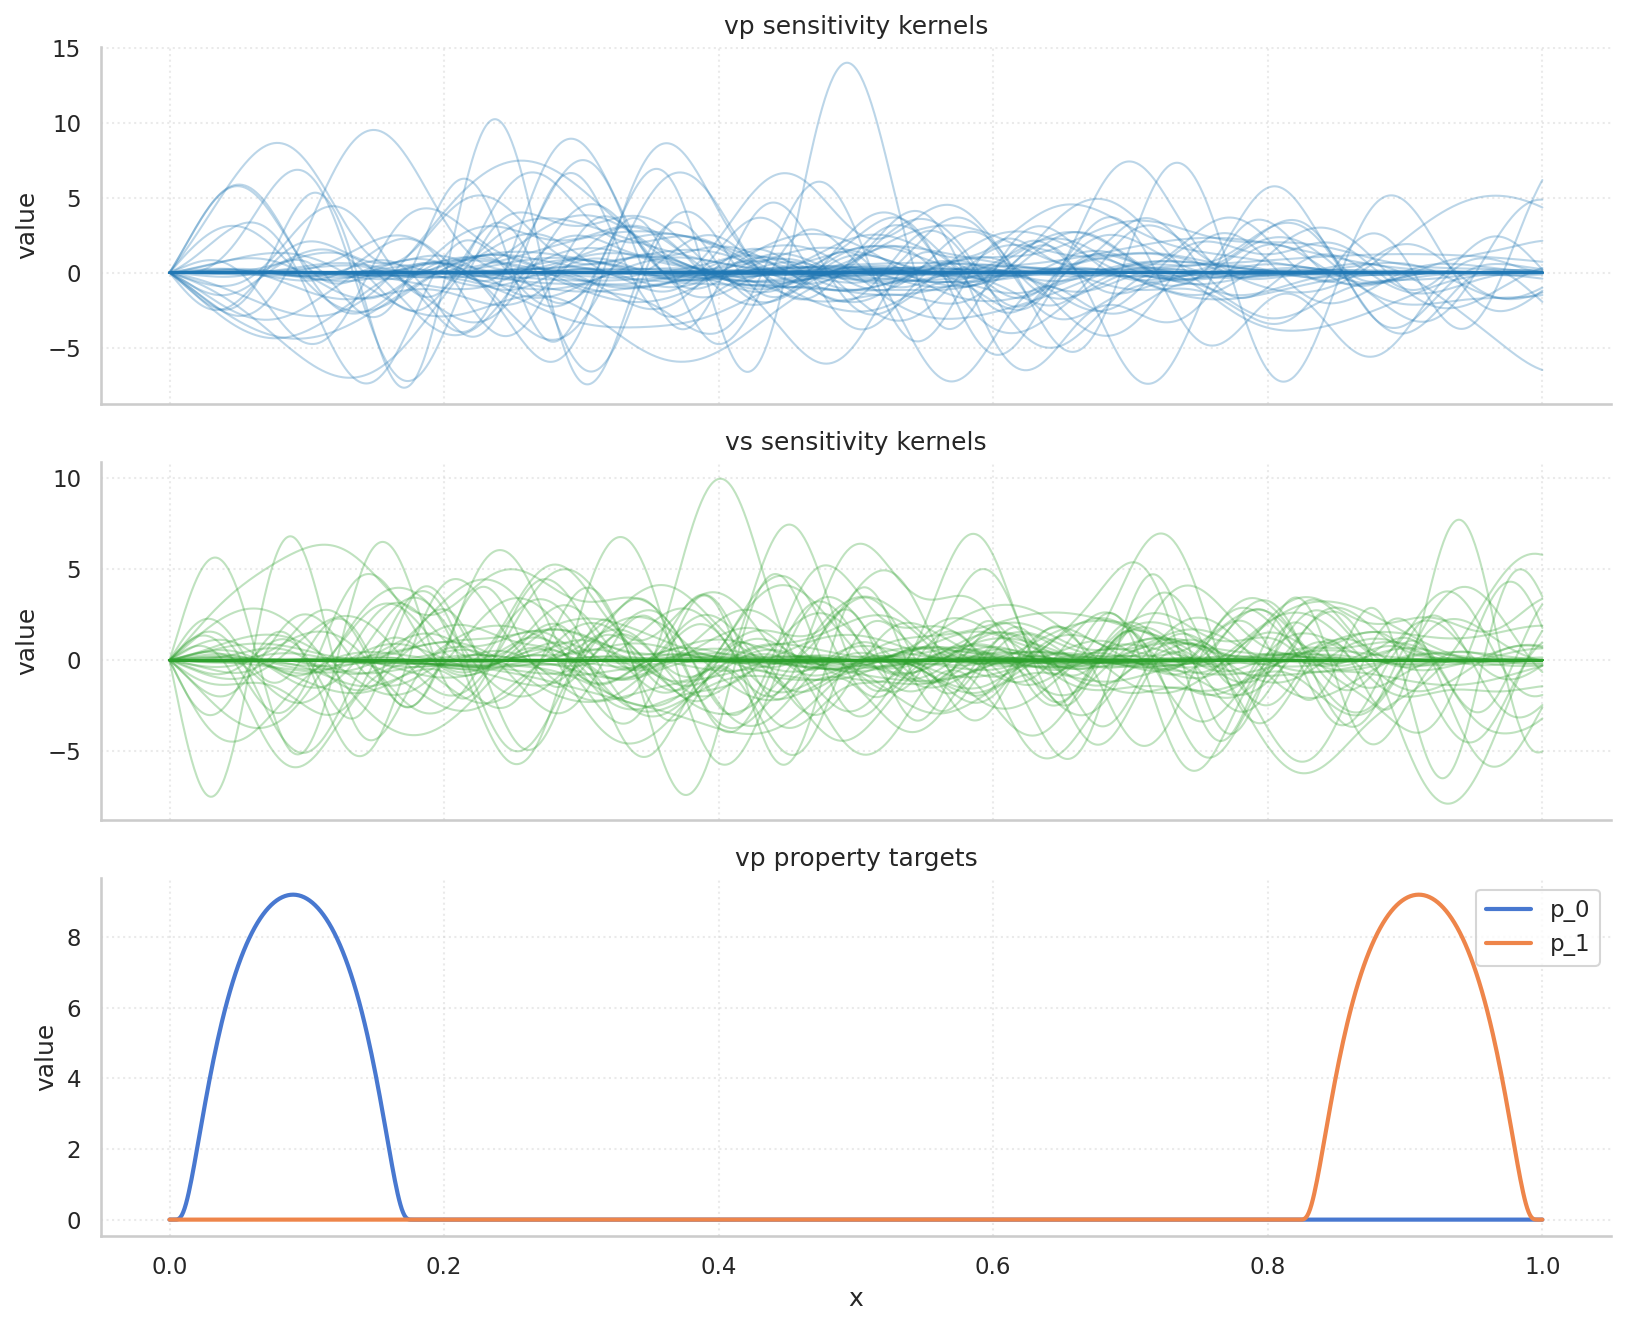

In [4]:
fig, axs = plt.subplots(3, 1, figsize=(11, 9), dpi=150, sharex=True)

for i in range(N_d):
    axs[0].plot(x, G_vp.get_kernel(i).evaluate(x), color='tab:blue', alpha=0.3, linewidth=1.0)
axs[0].set_title('vp sensitivity kernels')
axs[0].set_ylabel('value')
axs[0].grid(True, linestyle=':', alpha=0.4)

for i in range(N_d):
    axs[1].plot(x, G_vs.get_kernel(i).evaluate(x), color='tab:green', alpha=0.3, linewidth=1.0)
axs[1].set_title('vs sensitivity kernels')
axs[1].set_ylabel('value')
axs[1].grid(True, linestyle=':', alpha=0.4)

for i in range(N_p):
    axs[2].plot(x, T_vp.get_kernel(i).evaluate(x), linewidth=2.0, label=f'p_{i}')
axs[2].set_title('vp property targets')
axs[2].set_xlabel('x')
axs[2].set_ylabel('value')
axs[2].legend()
axs[2].grid(True, linestyle=':', alpha=0.4)

sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(figures_folder, 'ellipsoid_dli_kernels.png'), dpi=200, bbox_inches='tight')
plt.show()

## True Model and Synthetic Data

The true model uses seeded cosine-series `Function` objects for both `vp` and `vs` components. This keeps the model continuous and reproducible without introducing a finite basis in model space. Noise is heteroscedastic: each datum has its own per-datum standard deviation drawn from a linearly spaced $\sigma_d$ vector.

True properties : [ 0.60633 -0.76471]
σ_d range       : [0.06000, 0.12000]
||d_bar||       : 10.21787
||noise||       : 0.80600


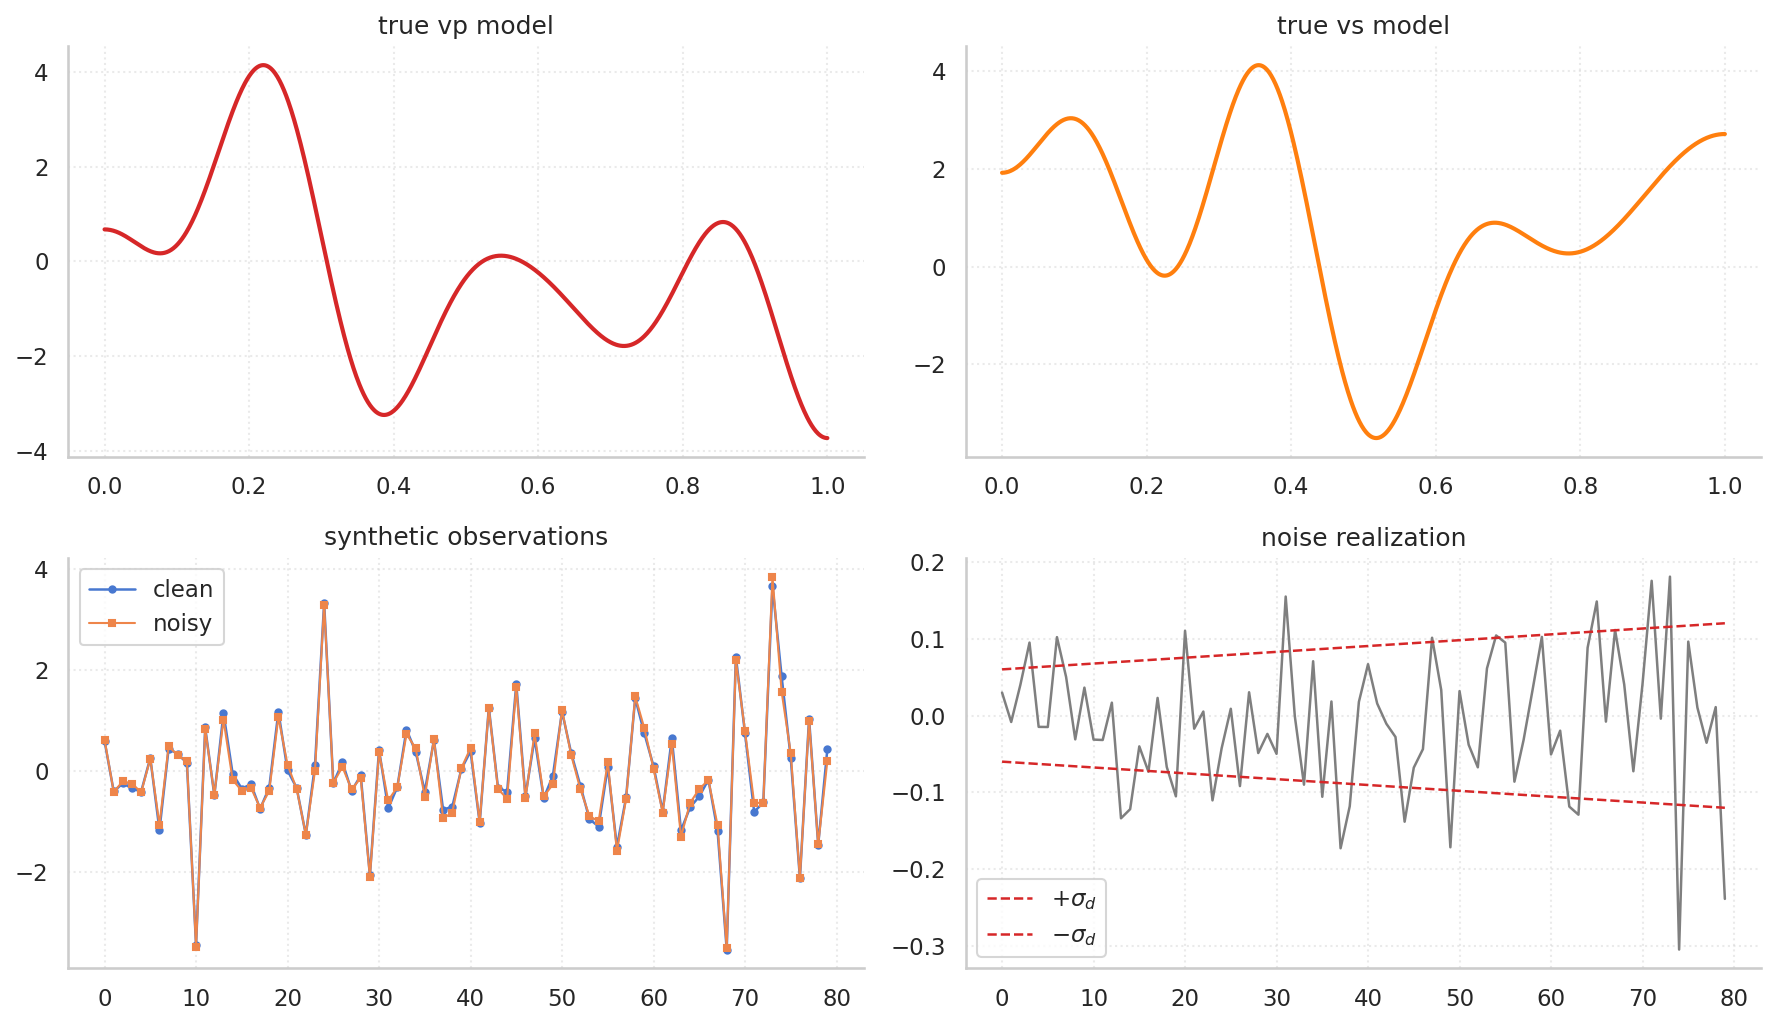

In [13]:
def cosine_series_function(space, coeffs):
    """Build a callable Function from an L2-normalised cosine series."""
    coeffs = np.asarray(coeffs, dtype=float)
    a = space.function_domain.a
    b = space.function_domain.b
    length = b - a

    def evaluate(x):
        x = np.asarray(x, dtype=float)
        xi = (x - a) / length
        values = np.zeros_like(xi, dtype=float)
        if coeffs.size > 0:
            values += coeffs[0] / np.sqrt(length)
        for k, ck in enumerate(coeffs[1:], start=1):
            values += ck * np.sqrt(2.0 / length) * np.cos(np.pi * k * xi)
        return values

    return Function(space, evaluate_callable=evaluate)


vp_coeffs = np.random.RandomState(42).uniform(-1.0, 1.0, N)
vs_coeffs = np.random.RandomState(24).uniform(-1.0, 1.0, N)

m_bar_vp = cosine_series_function(M_vp, vp_coeffs)
m_bar_vs = cosine_series_function(M_vs, vs_coeffs)
m_bar = [m_bar_vp, m_bar_vs]

true_props = T(m_bar)
d_bar = G(m_bar)

# Heteroscedastic diagonal noise
sigma_d_base   = 0.06
sigma_d_spread = 2.0
sigma_d = sigma_d_base * np.linspace(1.0, sigma_d_spread, N_d)

np.random.seed(42)
noise_vector = np.random.normal(0.0, sigma_d)
d_tilde = d_bar + noise_vector

print(f'True properties : {np.round(true_props, 5)}')
print(f'σ_d range       : [{sigma_d.min():.5f}, {sigma_d.max():.5f}]')
print(f'||d_bar||       : {D.norm(d_bar):.5f}')
print(f'||noise||       : {D.norm(noise_vector):.5f}')

fig, axs = plt.subplots(2, 2, figsize=(12, 7), dpi=150)
axs[0, 0].plot(x, m_bar_vp.evaluate(x), color='tab:red', linewidth=2.0)
axs[0, 0].set_title('true vp model')
axs[0, 0].grid(True, linestyle=':', alpha=0.4)

axs[0, 1].plot(x, m_bar_vs.evaluate(x), color='tab:orange', linewidth=2.0)
axs[0, 1].set_title('true vs model')
axs[0, 1].grid(True, linestyle=':', alpha=0.4)

axs[1, 0].plot(np.arange(N_d), d_bar, marker='o', markersize=3, linewidth=1.2, label='clean')
axs[1, 0].plot(np.arange(N_d), d_tilde, marker='s', markersize=3, linewidth=1.0, label='noisy')
axs[1, 0].set_title('synthetic observations')
axs[1, 0].legend()
axs[1, 0].grid(True, linestyle=':', alpha=0.4)

axs[1, 1].plot(np.arange(N_d), noise_vector, color='tab:gray', linewidth=1.2)
axs[1, 1].plot(np.arange(N_d),  sigma_d, '--', color='tab:red', linewidth=1.2, label=r'$+\sigma_d$')
axs[1, 1].plot(np.arange(N_d), -sigma_d, '--', color='tab:red', linewidth=1.2, label=r'$-\sigma_d$')
axs[1, 1].set_title('noise realization')
axs[1, 1].legend()
axs[1, 1].grid(True, linestyle=':', alpha=0.4)

sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(figures_folder, 'ellipsoid_dli_data.png'), dpi=200, bbox_inches='tight')
plt.show()

## Model Prior — Bessel-Sobolev Confidence Ellipsoid

The model prior is a **deterministic confidence ellipsoid** derived from block-diagonal Matérn-like covariances on the basis-free vp and vs spaces:
$$
C_0 = \begin{pmatrix} C_{0,vp} & 0 \\ 0 & C_{0,vs} \end{pmatrix}, \qquad
C_{0,vp} = \left(k_{vp}^2\,I + L_{vp}\right)^{-s_{vp}/2},
$$
where $L_{vp} = -\alpha_{vp}\Delta \geq 0$ is the positive (Neumann) Laplacian scaled by $\alpha_{vp}$, and similarly for $vs$. This matches the **eigenvalue convention** of `BesselSobolevInverse(k, s, L)`, which scales the $i$-th Laplacian mode by $(k^2 + \lambda_i)^{-s/2}$.

**Amplitude convention (`dc_variance`).** With $\alpha_{vp} = \ell_{vp}^2\,k_{vp}^2$, the eigenvalue of $C_{0,vp}$ at mode $i$ factors as
$$
k_{vp}^{-s_{vp}}\bigl(1 + \ell_{vp}^2\,\lambda_i(-\Delta)\bigr)^{-s_{vp}/2},
$$
so the DC (zero-frequency, $\lambda_0 = 0$) eigenvalue equals exactly $k_{vp}^{-s_{vp}}$. We choose
$$
k_{vp} = \text{dc\_variance}_{vp}^{-1/s_{vp}}
\quad\Longrightarrow\quad
\text{DC eigenvalue of } C_{0,vp} = \text{dc\_variance}_{vp}.
$$
The parameter `dc_variance` is therefore the **DC variance** of the prior covariance; correlation shape is controlled separately by `length_scale` and is independent of `dc_variance`.

The ellipsoid is
$$
\mathcal{E} = \bigl\{\,m : \langle C_0^{-1}\,m,\,m\rangle_{\mathcal{M}}
              \leq \chi^2_{d_{\rm eff}}(0.95)\bigr\},
$$
where $C_0^{-1}$ is implemented by `BesselSobolev(k, s, L)` (scaling by $(k^2 + \lambda_i)^{s/2}$), and $d_{\rm eff}$ is determined at runtime by **KL truncation** — counting modes whose eigenvalue exceeds $10^{-4}$ times the leading eigenvalue, summed over both blocks.

The support function of $\mathcal{E}$ is
$$
\sigma_{\mathcal{E}}(v) = \sqrt{\chi^2_{d_{\rm eff}}(0.95)}\,\bigl\|\,C_0^{1/2}\,v\,\bigr\|_{\mathcal{M}},
$$
where $C_0^{1/2}$ is `BesselSobolevInverse(k, s/2, L)` (scaling by $(k^2 + \lambda_i)^{-s/4}$). Implemented via `EllipsoidSupportFunction` with `BlockDiagonalLinearOperator` composition — **no dense covariance matrices and no model-space discretisation**.


In [14]:
# ============================================================
# Model Prior Ellipsoid — Operator-Native Construction
# (No dense matrices; BesselSobolev / BesselSobolevInverse +
#  BlockDiagonalLinearOperator assembly)
# ============================================================

# ---- Covariance hyperparameters ----------------------------------
# BesselSobolevInverse(k, s, L) implements eigenvalue scaling (k² + λᵢ)^{-s/2}
#   C_0       = BesselSobolevInverse(k, s,   L)   → (k² + λ)^{-s/2}
#   C_0^{1/2} = BesselSobolevInverse(k, s/2, L)   → (k² + λ)^{-s/4}
#   A=C_0⁻¹  = BesselSobolev      (k, s,   L)   → (k² + λ)^{ s/2}
#
# dc_variance : DC (zero-mode) variance of C_0  (eigenvalue of C_0 at λ=0)
#   With α = ℓ²k², eigenvalue at mode i = k^{-s}·(1 + ℓ²λᵢ(-Δ))^{-s/2},
#   so the DC eigenvalue is exactly k^{-s} = dc_variance.
#   Convention: k = dc_variance^{-1/s}
# alpha = length_scale^2 * k^2  (correlation shape is independent of dc_variance)

s_vp            = 3.0
length_scale_vp = 0.20
dc_variance_vp  = 2.0          # DC eigenvalue of C_0_vp (zero-mode variance)

s_vs            = 3.0
length_scale_vs = 0.15
dc_variance_vs  = 2.0          # DC eigenvalue of C_0_vs (zero-mode variance)

k_vp   = dc_variance_vp ** (-1.0 / s_vp)
k_vs   = dc_variance_vs ** (-1.0 / s_vs)
alpha_vp = (length_scale_vp ** 2) * (k_vp ** 2)
alpha_vs = (length_scale_vs ** 2) * (k_vs ** 2)

print('Covariance hyperparameters:')
print(f'  vp:  s={s_vp}, L_corr={length_scale_vp}, dc_var={dc_variance_vp}')
print(f'       k={k_vp:.4f},  α={alpha_vp:.4f}')
print(f'  vs:  s={s_vs}, L_corr={length_scale_vs}, dc_var={dc_variance_vs}')
print(f'       k={k_vs:.4f},  α={alpha_vs:.4f}')

# ---- Boundary conditions (Neumann on both ends for smooth priors) ----
bcs_vp = BoundaryConditions(bc_type='neumann')
bcs_vs = BoundaryConditions(bc_type='neumann')

# ---- Laplacian operators (spectral, helper dofs = N) ----------------
_dofs_cov = N
_nsamp_cov = 512

print(f'\nBuilding spectral Laplacian operators (dofs={_dofs_cov}) ...')
L_vp = Laplacian(
    M_vp, bcs_vp, alpha_vp,
    method='spectral', dofs=_dofs_cov,
    integration_config=sola_integration_cfg,
    n_samples=_nsamp_cov,
)
L_vs = Laplacian(
    M_vs, bcs_vs, alpha_vs,
    method='spectral', dofs=_dofs_cov,
    integration_config=sola_integration_cfg,
    n_samples=_nsamp_cov,
)

# ---- Covariance operators: eigenvalue scaling (k² + λᵢ)^{±s/2} ------
print('Building covariance, square-root, and shape operators ...')
C_0_vp      = BesselSobolevInverse(M_vp, M_vp, k_vp, s_vp,       L_vp, dofs=_dofs_cov, n_samples=_nsamp_cov)
C_0_vs      = BesselSobolevInverse(M_vs, M_vs, k_vs, s_vs,       L_vs, dofs=_dofs_cov, n_samples=_nsamp_cov)
C_0_sqrt_vp = BesselSobolevInverse(M_vp, M_vp, k_vp, 0.5*s_vp,  L_vp, dofs=_dofs_cov, n_samples=_nsamp_cov)
C_0_sqrt_vs = BesselSobolevInverse(M_vs, M_vs, k_vs, 0.5*s_vs,  L_vs, dofs=_dofs_cov, n_samples=_nsamp_cov)
A_vp        = BesselSobolev(       M_vp, M_vp, k_vp, s_vp,       L_vp, dofs=_dofs_cov, n_samples=_nsamp_cov)
A_vs        = BesselSobolev(       M_vs, M_vs, k_vs, s_vs,       L_vs, dofs=_dofs_cov, n_samples=_nsamp_cov)
print('  done.')

# ---- KL truncation: effective degrees of freedom ---------------------
KL_TOL = 1e-4

def _count_sig_modes(cov_op, n_modes, tol):
    """Count KL modes whose eigenvalue >= tol * max_eigenvalue."""
    sampler = KLSampler(cov_op, n_modes=n_modes)
    eigs = np.array([sampler.eigenvalue(i) for i in range(n_modes)])
    n_sig = int(np.sum(eigs >= tol * eigs.max()))
    return n_sig, eigs

n_sig_vp, ev_vp = _count_sig_modes(C_0_vp, N, KL_TOL)
n_sig_vs, ev_vs = _count_sig_modes(C_0_vs, N, KL_TOL)

dof_eff = n_sig_vp + n_sig_vs
chi2_ppf_model = float(scipy_chi2.ppf(0.95, df=dof_eff))
chi2_radius_95 = float(np.sqrt(chi2_ppf_model))

print(f'\nSignificant KL modes (tol={KL_TOL}):')
print(f'  vp: {n_sig_vp}/{N}   top-3 eigvals: {np.round(ev_vp[:3], 5)}')
print(f'  vs: {n_sig_vs}/{N}   top-3 eigvals: {np.round(ev_vs[:3], 5)}')
print(f'  DC eigenvalue check: C_0_vp DC ≈ {ev_vp[0]:.5f}  (expected dc_var={dc_variance_vp})')
print(f'Effective dof = {dof_eff},  χ²(0.95) = {chi2_ppf_model:.4f},  r_95 = {chi2_radius_95:.4f}')

# ---- Block-diagonal assembly --- pure operator composition, no matrix ----
C_0_model      = BlockDiagonalLinearOperator([C_0_vp, C_0_vs])
C_0_sqrt_model = BlockDiagonalLinearOperator([C_0_sqrt_vp, C_0_sqrt_vs])
A_model_op     = BlockDiagonalLinearOperator([A_vp, A_vs])

# ---- EllipsoidSupportFunction: E = {m : <C_0^{-1} m, m> <= r^2} --------
m_0 = M_model.zero
model_prior_support = EllipsoidSupportFunction(
    M_model,
    center=m_0,
    radius=chi2_radius_95,
    shape_operator=A_model_op,
    inverse_operator=C_0_model,
    inverse_sqrt_operator=C_0_sqrt_model,
)

# ---- Sanity checks -------------------------------------------------------
mahal_sq_mbar = float(M_model.inner_product(m_bar, A_model_op(m_bar)))
inside_prior  = bool(mahal_sq_mbar <= chi2_ppf_model)
_sf0 = model_prior_support(m_0)

print(f'\nSanity checks:')
print(f'  M_vp.dim = {M_vp.dim}  (basis-free: expected 0)')
print(f'  M_vs.dim = {M_vs.dim}  (basis-free: expected 0)')
print(f'  Mahalanobis² of m̄     = {mahal_sq_mbar:.4f}  (threshold {chi2_ppf_model:.4f})')
print(f'  m̄ ∈ prior ellipsoid   = {inside_prior}')
print(f'  σ_ε(0) (must be 0.0)  = {_sf0:.6f}')

_test_v = T.adjoint(P.basis_vector(0))
_sfv    = model_prior_support(_test_v)
_ip_mbar = M_model.inner_product(_test_v, m_bar)
print(f'  σ_ε(T*e_0) = {_sfv:.4f},  ⟨T*e_0, m̄⟩ = {_ip_mbar:.4f}  (σ ≥ ip: {_sfv >= _ip_mbar - 1e-10})')


Covariance hyperparameters:
  vp:  s=3.0, L_corr=0.2, dc_var=2.0
       k=0.7937,  α=0.0252
  vs:  s=3.0, L_corr=0.15, dc_var=2.0
       k=0.7937,  α=0.0142

Building spectral Laplacian operators (dofs=10) ...
Building covariance, square-root, and shape operators ...
  done.

Significant KL modes (tol=0.0001):
  vp: 10/10   top-3 eigvals: [2.      1.97052 1.8863 ]
  vs: 10/10   top-3 eigvals: [2.      1.99059 1.96281]
  DC eigenvalue check: C_0_vp DC ≈ 2.00000  (expected dc_var=2.0)
Effective dof = 20,  χ²(0.95) = 31.4104,  r_95 = 5.6045

Sanity checks:
  M_vp.dim = 0  (basis-free: expected 0)
  M_vs.dim = 0  (basis-free: expected 0)
  Mahalanobis² of m̄     = 4.9581  (threshold 31.4104)
  m̄ ∈ prior ellipsoid   = True
  σ_ε(0) (must be 0.0)  = 0.000000
  σ_ε(T*e_0) = 18.5400,  ⟨T*e_0, m̄⟩ = 0.6063  (σ ≥ ip: True)


## Property Prior Bounds

We first compute the **prior-only** property bounds induced by $\mathcal{E}$ alone, ignoring data. These serve as a baseline for the later posterior intervals: the data-confidence ellipsoid can only tighten them, never widen them.

Property prior bounds (from ellipsoid only, no data):
  p_0: [-18.5400, 18.5400]  true=0.6063  inside=True
  p_1: [-18.5400, 18.5400]  true=-0.7647  inside=True


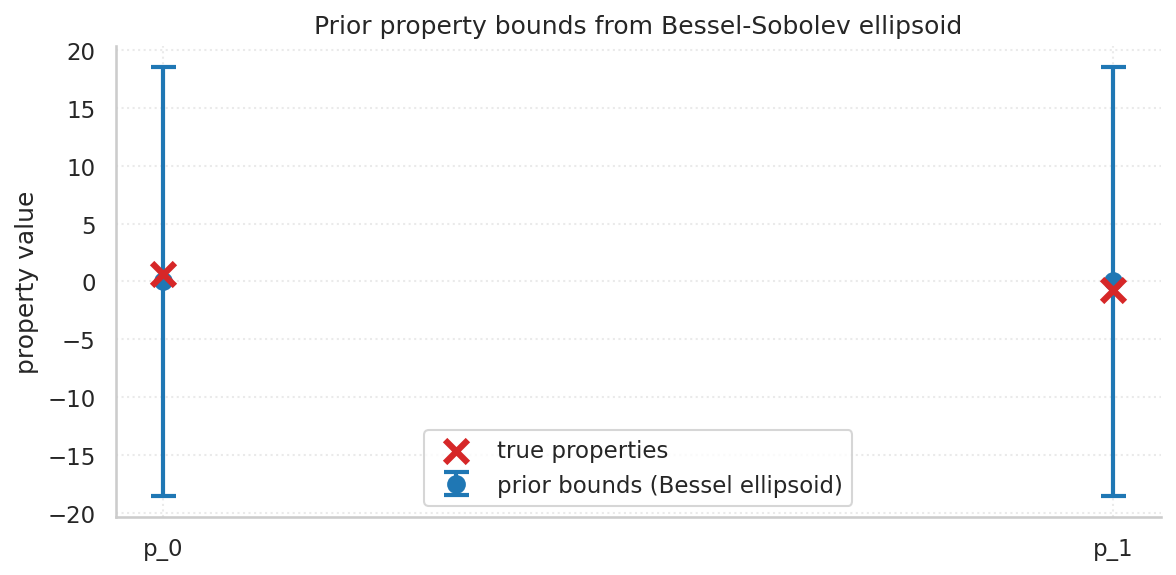


PRIOR-ONLY BASELINE
Model blocks          : M_vp ⊕ M_vs  (both basis=None)
Prior type            : Bessel-Sobolev confidence ellipsoid
Effective dof         : 20
Ellipsoid radius √χ²  : 5.6045
Mean prior half-width : 18.54000
True props captured   : 2/2
The following sections add the heteroscedastic data ellipsoid and the DLI posterior solve.


In [22]:
prior_qs    = [P.basis_vector(i) for i in range(P.dim)]
prior_upper = np.array([model_prior_support(T.adjoint(q)) for q in prior_qs])
prior_lower = np.array([
    -model_prior_support(M_model.multiply(-1.0, T.adjoint(q)))
    for q in prior_qs
])
prior_mid  = 0.5 * (prior_lower + prior_upper)
prior_half = 0.5 * (prior_upper - prior_lower)

print('Property prior bounds (from ellipsoid only, no data):')
for i in range(N_p):
    inside = prior_lower[i] <= true_props[i] <= prior_upper[i]
    print(f'  p_{i}: [{prior_lower[i]:.4f}, {prior_upper[i]:.4f}]  '
          f'true={true_props[i]:.4f}  inside={inside}')

fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
ax.errorbar(
    np.arange(N_p), prior_mid, yerr=prior_half, fmt='o',
    color='tab:blue', capsize=6, capthick=2, markersize=8, linewidth=2,
    label='prior bounds (Bessel ellipsoid)'
)
ax.scatter(
    np.arange(N_p), true_props, color='tab:red', marker='x',
    s=120, linewidths=3, zorder=10, label='true properties'
)
ax.set_xticks(np.arange(N_p))
ax.set_xticklabels([f'p_{i}' for i in range(N_p)])
ax.set_ylabel('property value')
ax.set_title('Prior property bounds from Bessel-Sobolev ellipsoid')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(figures_folder, 'ellipsoid_dli_prior_bounds.png'), dpi=200, bbox_inches='tight')
plt.show()

print('\n' + '=' * 60)
print('PRIOR-ONLY BASELINE')
print('=' * 60)
print(f'Model blocks          : M_vp ⊕ M_vs  (both basis=None)')
print(f'Prior type            : Bessel-Sobolev confidence ellipsoid')
print(f'Effective dof         : {dof_eff}')
print(f'Ellipsoid radius √χ²  : {chi2_radius_95:.4f}')
print(f'Mean prior half-width : {np.mean(prior_half):.5f}')
print(f'True props captured   : {sum(prior_lower[i] <= true_props[i] <= prior_upper[i] for i in range(N_p))}/{N_p}')
print('=' * 60)
print('The following sections add the heteroscedastic data ellipsoid and the DLI posterior solve.')

## Data-Confidence Ellipsoid (Heteroscedastic)

The data noise model is a diagonal Gaussian with per-datum standard deviations $\sigma_{d,i}$, giving the **heteroscedastic data covariance** $C_D = \mathrm{diag}(\sigma_{d,1}^2, \ldots, \sigma_{d,N_d}^2)$.

The corresponding 0.95-confidence data ellipsoid is
$$
\mathcal{V} = \bigl\{\,\eta \in \mathbb{R}^{N_d} : \|\eta\|^2_{C_D^{-1}} \leq \chi^2_{N_d}(0.95)\bigr\},
$$
where $\|\eta\|^2_{C_D^{-1}} = \sum_i \eta_i^2 / \sigma_{d,i}^2$ is the Mahalanobis norm squared under $C_D$.

Its support function is
$$
\sigma_{\mathcal{V}}(v) = \sqrt{\chi^2_{N_d}(0.95)}\,\|C_D^{1/2} v\|_D = \sqrt{\chi^2_{N_d}(0.95)}\,\bigl(\textstyle\sum_i \sigma_{d,i}^2 v_i^2\bigr)^{1/2}.
$$

Because $D = \mathbb{R}^{N_d}$ is finite-dimensional, all three operators ($C_D^{-1}$, $C_D$, $C_D^{1/2}$) are stored as `DiagonalSparseMatrixLinearOperator` — no dense $N_d \times N_d$ matrix is allocated.


In [17]:
# ============================================================
# Data-Confidence Ellipsoid — Heteroscedastic Diagonal C_D
# V = { η ∈ ℝ^{N_d} : Σ_i (η_i / σ_d_i)² ≤ χ²_{N_d}(0.95) }
# All operators stored as sparse diagonal — no dense N_d × N_d matrix.
# ============================================================

chi2_ppf_data    = float(scipy_chi2.ppf(0.95, df=N_d))
chi2_radius_data = float(np.sqrt(chi2_ppf_data))

A_d      = DiagonalSparseMatrixLinearOperator.from_diagonal_values(D, D, 1.0 / sigma_d**2)
C_d      = DiagonalSparseMatrixLinearOperator.from_diagonal_values(D, D, sigma_d**2)
C_d_sqrt = DiagonalSparseMatrixLinearOperator.from_diagonal_values(D, D, sigma_d)

data_error_support = EllipsoidSupportFunction(
    D,
    center=D.zero,
    radius=chi2_radius_data,
    shape_operator=A_d,
    inverse_operator=C_d,
    inverse_sqrt_operator=C_d_sqrt,
)

# Sanity: is the realised noise inside V?
mahal_sq_noise = float(np.sum((noise_vector / sigma_d)**2))
noise_inside_V = bool(mahal_sq_noise <= chi2_ppf_data)
sf_at_zero_d   = data_error_support(D.zero)

print('Data ellipsoid (heteroscedastic C_D = diag(σ_d²)):')
print(f'  χ²(0.95, df={N_d}) = {chi2_ppf_data:.4f},  r_data = {chi2_radius_data:.4f}')
print(f'  σ_d range          : [{sigma_d.min():.5f}, {sigma_d.max():.5f}]')
print(f'  Mahal²(noise)      = {mahal_sq_noise:.4f}  (threshold {chi2_ppf_data:.4f})')
print(f'  noise ∈ V          : {noise_inside_V}')
print(f'  σ_V(0) (must 0.0)  : {sf_at_zero_d:.8f}')


Data ellipsoid (heteroscedastic C_D = diag(σ_d²)):
  χ²(0.95, df=80) = 101.8795,  r_data = 10.0935
  σ_d range          : [0.06000, 0.12000]
  Mahal²(noise)      = 73.6521  (threshold 101.8795)
  noise ∈ V          : True
  σ_V(0) (must 0.0)  : 0.00000000


## DLI Solve — Ellipsoidal Model and Data Constraints

With both constraints in place, the admissible property set $\mathcal{U} = \mathcal{T}(\mathcal{E} \cap G^{-1}(\tilde{d} - \mathcal{V}))$ has support function
$$
h_{\mathcal{U}}(q) = \inf_{\lambda \in D}\bigl\{\langle\lambda,\tilde{d}\rangle_D + \sigma_{\mathcal{E}}(T^* q - G^*\lambda) + \sigma_{\mathcal{V}}(-\lambda)\bigr\}.
$$

This is minimised by `ProximalBundleMethod` for the $+e_i$ and $-e_i$ standard-basis directions in property space $P = \mathbb{R}^{N_p}$, giving posterior upper and lower bounds:
$$
\mathcal{U}_i^+ = h_{\mathcal{U}}(e_i), \qquad \mathcal{U}_i^- = -h_{\mathcal{U}}(-e_i).
$$

The solve is done sequentially with warm-starting (`n_jobs=1, warm_start=True`) since $N_p$ is small.


In [18]:
# ============================================================
# DLI Solve — ProximalBundleMethod on ±e_i directions
# ============================================================

cost = DualMasterCostFunction(
    D, P, M_model,
    G, T,
    model_prior_support,
    data_error_support,
    d_tilde,
    P.basis_vector(0),
)

bundle_solver = ProximalBundleMethod(
    cost,
    rho0=1.0,
    rho_factor=2.0,
    tolerance=1e-4,
    max_iterations=500,
    bundle_size=50,
    qp_solver=best_available_qp_solver(),
)

basis_dirs     = [P.basis_vector(i) for i in range(P.dim)]
neg_basis_dirs = [P.multiply(-1.0, P.basis_vector(i)) for i in range(P.dim)]
lambda0        = D.zero

print(f'Running DLI solve for {N_p} property dimensions ({2 * N_p} directions)...')
solve_t0 = time.perf_counter()

upper_values, _, upper_diag = solve_support_values(
    cost, basis_dirs, bundle_solver, lambda0, warm_start=True, n_jobs=1
)
lower_neg_values, _, lower_diag = solve_support_values(
    cost, neg_basis_dirs, bundle_solver, lambda0, warm_start=True, n_jobs=1
)

solve_elapsed = time.perf_counter() - solve_t0
lower_values  = -lower_neg_values

post_mid   = 0.5 * (lower_values + upper_values)
post_half  = 0.5 * (upper_values - lower_values)
within_post = int(np.sum((true_props >= lower_values) & (true_props <= upper_values)))
total_iters = sum(d.num_iterations for d in upper_diag + lower_diag)

print(f'Solve time              : {solve_elapsed:.2f} s')
print(f'Total bundle iterations : {total_iters}')
print(f'True properties captured: {within_post}/{N_p}')
print()
print('Posterior intervals:')
for i in range(N_p):
    inside = lower_values[i] <= true_props[i] <= upper_values[i]
    print(
        f'  p_{i}: [{lower_values[i]:.4f}, {upper_values[i]:.4f}]  '
        f'(prior: [{prior_lower[i]:.4f}, {prior_upper[i]:.4f}])  '
        f'true={true_props[i]:.4f}  inside={inside}'
    )


Running DLI solve for 2 property dimensions (4 directions)...
Solve time              : 18.81 s
Total bundle iterations : 377
True properties captured: 2/2

Posterior intervals:
  p_0: [-0.0195, 0.9877]  (prior: [-18.5400, 18.5400])  true=0.6063  inside=True
  p_1: [-1.7517, 0.0729]  (prior: [-18.5400, 18.5400])  true=-0.7647  inside=True


Sanity check PASSED: all posterior half-widths ≤ prior half-widths (within solver tolerance)


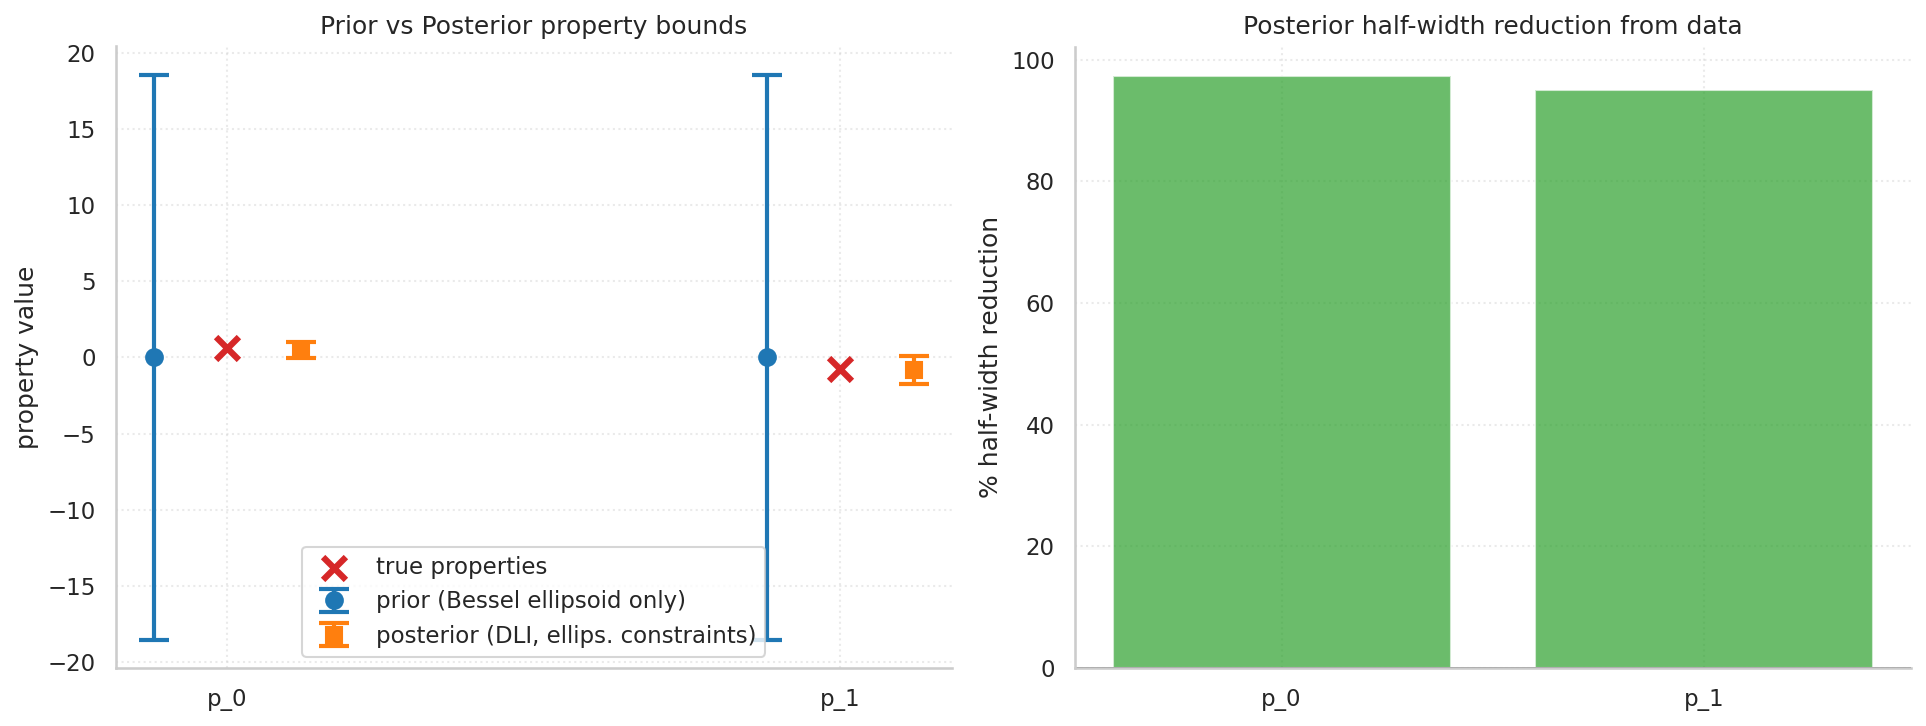


RESULTS SUMMARY — Ellipsoidal DLI Demo
Model prior     : Bessel-Sobolev operator ellipsoid (basis-free)
Data constraint : Heteroscedastic diagonal C_D ellipsoid
Solve time      : 18.81 s
Bundle iters    : 377
True props ok   : 2/2
Mean prior half-width     : 18.54000
Mean posterior half-width : 0.70792
Mean reduction            : 96.2%


In [23]:
# ============================================================
# Posterior Sanity Checks and Summary
# ============================================================
# Key invariant: data constraints can only tighten bounds, never widen them.
# Posterior half-widths must not exceed prior half-widths (up to solver tolerance).

tol_sanity = 1e-3  # solver tolerance used above is 1e-4; add small margin
assert np.all(post_half <= prior_half + tol_sanity), (
    f'Posterior wider than prior at indices '
    f'{np.where(post_half > prior_half + tol_sanity)[0]} — '
    f'post_half={post_half}, prior_half={prior_half}'
)
print('Sanity check PASSED: all posterior half-widths ≤ prior half-widths (within solver tolerance)')

reduction_pct = (prior_half - post_half) / np.maximum(prior_half, 1e-12) * 100.0

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=150)

# Panel 1: prior vs posterior interval comparison
ax = axes[0]
props_idx = np.arange(N_p)
ax.errorbar(
    props_idx - 0.12, prior_mid, yerr=prior_half, fmt='o',
    color='tab:blue', capsize=7, capthick=2, markersize=8, linewidth=2,
    label='prior (Bessel ellipsoid only)',
)
ax.errorbar(
    props_idx + 0.12, post_mid, yerr=post_half, fmt='s',
    color='tab:orange', capsize=7, capthick=2, markersize=8, linewidth=2,
    label='posterior (DLI, ellips. constraints)',
)
ax.scatter(
    props_idx, true_props, marker='x', color='tab:red',
    s=120, linewidths=3, zorder=10, label='true properties',
)
ax.set_xticks(props_idx)
ax.set_xticklabels([f'p_{i}' for i in range(N_p)])
ax.set_ylabel('property value')
ax.set_title('Prior vs Posterior property bounds')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.4)

# Panel 2: half-width reduction
ax = axes[1]
ax.bar(props_idx, reduction_pct, color='tab:green', alpha=0.7)
ax.set_xticks(props_idx)
ax.set_xticklabels([f'p_{i}' for i in range(N_p)])
ax.set_ylabel('% half-width reduction')
ax.set_title('Posterior half-width reduction from data')
ax.axhline(0, color='k', linewidth=0.8)
ax.grid(True, linestyle=':', alpha=0.4)

sns.despine()
plt.tight_layout()
plt.savefig(
    os.path.join(figures_folder, 'ellipsoid_dli_posterior.png'),
    dpi=200, bbox_inches='tight',
)
plt.show()

print()
print('=' * 60)
print('RESULTS SUMMARY — Ellipsoidal DLI Demo')
print('=' * 60)
print(f'Model prior     : Bessel-Sobolev operator ellipsoid (basis-free)')
print(f'Data constraint : Heteroscedastic diagonal C_D ellipsoid')
print(f'Solve time      : {solve_elapsed:.2f} s')
print(f'Bundle iters    : {total_iters}')
print(f'True props ok   : {within_post}/{N_p}')
print(f'Mean prior half-width     : {np.mean(prior_half):.5f}')
print(f'Mean posterior half-width : {np.mean(post_half):.5f}')
print(f'Mean reduction            : {np.mean(reduction_pct):.1f}%')
print('=' * 60)


## Key Takeaways

This notebook is the ellipsoidal counterpart of `synthetic_vp_vs_dli.ipynb`. The forward operator, property operator, and synthetic truth are intentionally similar, so the main differences come from the geometry of the constraint sets rather than from changing the physical setup.

| Feature | `synthetic_vp_vs_dli.ipynb` | `synthetic_vp_vs_ellipsoid_dli.ipynb` |
|---|---|---|
| Model prior | norm ball | Bessel-Sobolev ellipsoid |
| Data confidence set | norm ball | heteroscedastic diagonal ellipsoid |
| Correlation length / smoothness | not encoded | encoded through `BesselSobolev*` operators |
| Per-datum noise levels | not encoded | encoded through `diag(σ_d^2)` |
| Dense matrices | None | None |
| Effective dof | Fixed radius $r$ | KL truncation of Bessel-Sobolev prior |
| DLI cost / solve | `DualMasterCostFunction` + `ProximalBundleMethod` | identical |

A **norm ball** treats all directions in model space equally. The **Bessel-Sobolev ellipsoid** down-weights rough (high-wavenumber) perturbations relative to smooth ones, concentrating prior mass on models with correlation structure governed by $L_\mathrm{corr}$ and smoothness order $s$. This is the continuous, basis-free analogue of a Matérn-style prior.

The **heteroscedastic data ellipsoid** $\mathcal{V}$ extends the homoscedastic ball by assigning each datum its own noise level $\sigma_{d,i}$. The per-datum ellipsoid is strictly more informative than a uniform ball whenever the noise is unequal: it penalises directions where data quality is high and relaxes constraints where noise dominates. All three required operators ($C_D$, $C_D^{-1}$, $C_D^{1/2}$) are sparse diagonal objects, so no $N_d \times N_d$ dense matrix is ever assembled.

### Operator-Theoretic Construction

The model prior is built without ever calling `.matrix(...)` on a model-space operator:

1. `BesselSobolevInverse(k, s, L)` provides the covariance blocks $C_0$, scaling the $i$-th mode by $(k^2 + \lambda_i)^{-s/2}$.
2. `BesselSobolevInverse(k, s/2, L)` provides the covariance square-root blocks $C_0^{1/2}$, scaling by $(k^2 + \lambda_i)^{-s/4}$.
3. `BesselSobolev(k, s, L)` provides the shape blocks $C_0^{-1}$, scaling by $(k^2 + \lambda_i)^{s/2}$.
4. `BlockDiagonalLinearOperator` assembles the full model-space block structure, and `EllipsoidSupportFunction` wraps these operators in the support-function API used by `DualMasterCostFunction`.

Effective degrees of freedom $d_\mathrm{eff}$ are determined at runtime by `KLSampler` truncation, so the chi-squared threshold adapts to the actual spectral content of the prior rather than a hand-chosen grid size. This is the same operator-theoretic pattern used in `realistic_dli.ipynb` with real sensitivity kernels.